# 07 — Daily paths for backtesting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/07_daily_paths_for_backtesting.ipynb)

A strategy backtester brings daily returns and wants daily paths. Daily data has
what annual targets do not: volatility clustering and fat tails. The generator
is fitted on the standardized residuals of an AR(1)-GARCH(1,1) per asset
(`dynamics='ar1-garch'`, needs the `arch` package), the C-vine carries the
dependence between the residuals, and `simulate_paths` filters the simulated
residuals back through the GARCH from the last observed state.

Runtime: about 3 minutes.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

try:
    import arch
except ImportError:
    import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "arch"], check=True)
from cvinemarketgen import Targets, CVineMarket, load_daily_returns, exceedance_curve

cvinemarketgen 0.2.0


## Daily returns of four ETFs

SPY (U.S. equity), TLT (long Treasuries), GLD (gold), DBC (commodities), adjusted
closes from Yahoo Finance since 2010, cached in `data/daily_cache.csv`. Any
DataFrame of daily returns works the same way.

In [2]:
daily = load_daily_returns(["SPY", "TLT", "GLD", "DBC"], start="2010-01-01", cache=os.path.join(ROOT, "data", "daily_cache.csv"))
daily.tail()

daily returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/daily_cache.csv: 4197 days, 2010-01-05 to 2026-09-11


,SPY,TLT,GLD,DBC
date,,,,
2026-09-04,-0.003854,0.001706,-0.008410,-0.001877
2026-09-08,-0.005492,-0.000122,-0.017332,0.015674
2026-09-09,-0.004648,-0.005718,0.009081,0.013889
2026-09-10,-0.005994,-0.011624,-0.017330,0.023440
2026-09-11,0.008524,0.001114,0.006080,-0.013682


In [3]:
pd.concat([daily.mean().mul(252).rename("mean (ann.)"), daily.std().mul(252 ** 0.5).rename("vol (ann.)"),
           daily.skew().rename("skew"), (daily.kurtosis() + 3).rename("kurt")], axis=1).round(3)

,mean (ann.),vol (ann.),skew,kurt
SPY,0.147,0.171,-0.329,15.046
TLT,0.034,0.149,0.050,6.586
GLD,0.092,0.168,-0.544,9.012
DBC,0.042,0.174,-0.518,6.412


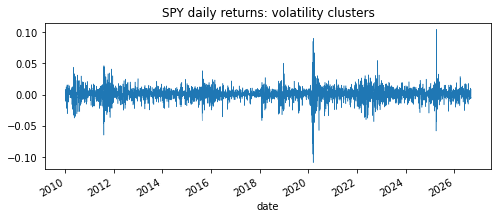

In [4]:
fig, ax = plt.subplots(figsize=(8, 3)); daily["SPY"].plot(ax=ax, lw=0.5); ax.set_title("SPY daily returns: volatility clusters"); plt.show()

## Targets are the sample, at daily frequency

In [5]:
t = Targets.from_history(daily)
print(t, "| frequency:", t.freq)

Targets(4 assets: SPY, TLT, GLD, DBC; layer=returns) | frequency: None


## Fit with AR(1)-GARCH dynamics

The dynamics are fitted first; the targets of the residual layer are the
sample moments of the standardized residuals; the families are selected on
them. `edges` and `marginals` describe the residual layer.

In [6]:
t0 = time.time()
cv = CVineMarket(t, central="SPY", families="auto", dynamics="ar1-garch").fit()
print(f"fit: {time.time() - t0:.0f} s")
cv.dynamics.params.round(4)

fit: 150 s


,a,b,omega,alpha,beta
SPY,0.0918,-0.0433,0.0386,0.1616,0.8038
TLT,0.0114,-0.0429,0.0133,0.0624,0.9218
GLD,0.0240,-0.0103,0.0215,0.0681,0.9134
DBC,0.0121,0.0146,0.0172,0.0678,0.9199


In [7]:
cv.edges

,tree,edge,selected family,parameters
0,1,"TLT , SPY",gumbel 90°,theta=1.171
1,1,"GLD , SPY",clayton 270° + gumbel 0°,"w=0.62, theta=(0.217, 1.400)"
2,1,"DBC , SPY",gumbel 180°,theta=1.258
3,2,"GLD , TLT | SPY",gaussian 0°,theta=0.268
4,2,"DBC , TLT | SPY",gaussian 0°,theta=-0.137
5,3,"DBC , GLD | SPY, TLT",gaussian 0°,theta=0.396


In [8]:
cv.fit_targets.summary();

Targets for 4 assets (residuals layer)
       mean     vol    skew    kurt
SPY -0.0494  0.9987 -0.6156  4.9180
TLT  0.0033  0.9999 -0.0930  3.6906
GLD  0.0129  1.0008 -0.2923  5.4555
DBC -0.0049  1.0006 -0.4391  5.0740

correlation matrix:
      SPY   TLT   GLD   DBC
SPY  1.00 -0.24  0.07  0.34
TLT -0.24  1.00  0.24 -0.22
GLD  0.07  0.24  1.00  0.32
DBC  0.34 -0.22  0.32  1.00

skewness and kurtosis: estimated from the history (4196 observations)


## Simulate 1,000 daily paths of one year

`Paths` holds an array `(n_paths, horizon, N)`; `to_frame()` gives the long
table a backtester loops over, `wide(asset)` one asset across paths,
`terminal()` the cumulative return at the horizon.

In [9]:
t0 = time.time()
P = cv.simulate_paths(n_paths=1000, horizon=252, seed=1)
print(P, f"({time.time() - t0:.0f} s)")
P.to_frame().head()

Paths(n_paths=1000, horizon=252, assets=4, returns) (40 s)


SPY       TLT       GLD       DBC
path t                                        
0    1 -0.000621  0.003674 -0.082682 -0.025183
     2 -0.006052 -0.007138 -0.029987 -0.011161
     3 -0.000284  0.001241 -0.003389  0.004047
     4 -0.004170  0.008078 -0.039009 -0.008329
     5  0.000050  0.000802 -0.022530 -0.013502

The pooled per-day moments of the paths against the history: the GARCH filter restores the fat tails and the AR(1) the small autocorrelation.

In [10]:
pd.concat([P.summary().add_suffix(" (paths)"), t.moments.add_suffix(" (history)")], axis=1).round(5)

,mean (paths),vol (paths),skew (paths),kurt (paths),mean (history),vol (history),skew (history),kurt (history)
SPY,0.00046,0.00996,-0.89396,15.02996,0.00058,0.01075,-0.32940,15.04617
TLT,0.00014,0.00864,-0.07771,5.11817,0.00014,0.00939,0.04990,6.58560
GLD,0.00037,0.01196,-0.36359,9.26716,0.00036,0.01056,-0.54381,9.01242
DBC,0.00006,0.01260,-0.57170,13.98203,0.00017,0.01097,-0.51780,6.41195


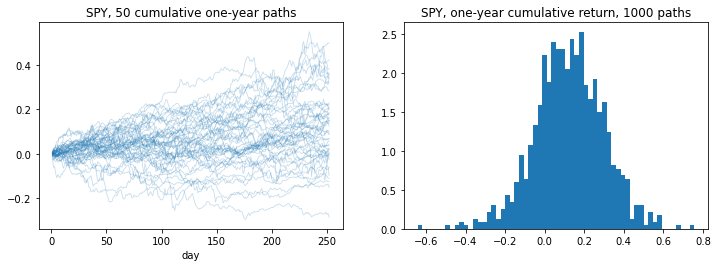

,SPY,TLT,GLD,DBC
0.01,-0.321,-0.224,-0.391,-0.494
0.05,-0.154,-0.168,-0.221,-0.313
0.50,0.125,0.026,0.085,0.008
0.95,0.398,0.264,0.447,0.363
0.99,0.528,0.406,0.689,0.566


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(P.cumulative().wide("SPY").iloc[:, :50], color="tab:blue", alpha=0.25, lw=0.8); axes[0].set_title("SPY, 50 cumulative one-year paths"); axes[0].set_xlabel("day")
axes[1].hist(P.terminal()["SPY"], bins=60, density=True); axes[1].set_title("SPY, one-year cumulative return, 1000 paths"); plt.show()
P.terminal().quantile([0.01, 0.05, 0.5, 0.95, 0.99]).round(3)

## Why the dynamics matter

The same vine without dynamics (`dynamics=None`) gives i.i.d. days. Both
versions match the unconditional moments of the history, kurtosis included,
because the marginals are fitted to them. What the i.i.d. version cannot have
is volatility clustering: the autocorrelation of squared returns, which is what
a daily backtest lives on. Compare it, then look at one simulated year of each.

In [12]:
cv0 = CVineMarket(t, central="SPY", families="auto").fit()
P0 = cv0.simulate_paths(n_paths=1000, horizon=252, seed=2)

def acf_sq(x, lags=(1, 5, 20)):
    x2 = pd.Series(np.asarray(x) ** 2)
    return pd.Series({f"lag {l}": x2.autocorr(l) for l in lags})

def acf_sq_paths(P, asset, lags=(1, 5, 20)):
    j = P.assets.index(asset)
    return pd.concat([acf_sq(P.array[i, :, j], lags) for i in range(200)], axis=1).mean(axis=1)

pd.DataFrame({"history": acf_sq(daily["SPY"]), "i.i.d. paths": acf_sq_paths(P0, "SPY"), "GARCH paths": acf_sq_paths(P, "SPY")}).round(3)

,history,i.i.d. paths,GARCH paths
lag 1,0.401,0.002,0.160
lag 5,0.266,-0.003,0.110
lag 20,0.100,-0.008,0.025


In [13]:
pd.DataFrame({"kurt, i.i.d. paths": P0.summary()["kurt"], "kurt, GARCH paths": P.summary()["kurt"], "kurt, history": t.kurt}).round(2)

,"kurt, i.i.d. paths","kurt, GARCH paths","kurt, history"
SPY,15.05,15.03,15.05
TLT,6.59,5.12,6.59
GLD,9.01,9.27,9.01
DBC,6.41,13.98,6.41


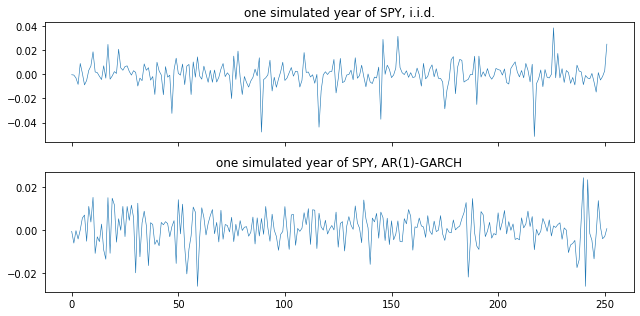

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
axes[0].plot(P0.array[0, :, 0], lw=0.6); axes[0].set_title("one simulated year of SPY, i.i.d.")
axes[1].plot(P.array[0, :, 0], lw=0.6); axes[1].set_title("one simulated year of SPY, AR(1)-GARCH"); plt.tight_layout(); plt.show()

## Save the fitted model, reload it later without refitting

In [15]:
cv.save("daily_market.json")
CVineMarket.load("daily_market.json").simulate_paths(5, 10, seed=1)

Paths(n_paths=5, horizon=10, assets=4, returns)